In [8]:
import mne
from config import BCI2A_PATH, MI_DATA_PATH, SAMPLING_RATE, LOW_FREQ, HIGH_FREQ
import os
import matplotlib.pyplot as plt

In [79]:
def load_sample_data():
    # Load BCI-2A dataset
    bci2a_files = [f for f in os.listdir(BCI2A_PATH) if f.endswith('.gdf')]
    
    raw = mne.io.read_raw_gdf(os.path.join(BCI2A_PATH, bci2a_files[0]), preload=True)
    # raw.resample(SAMPLING_RATE)
    # raw.filter(LOW_FREQ, HIGH_FREQ)
    return raw


In [75]:
montage = mne.channels.make_standard_montage('standard_1020')
print(montage.ch_names)

['Fp1', 'Fpz', 'Fp2', 'AF9', 'AF7', 'AF5', 'AF3', 'AF1', 'AFz', 'AF2', 'AF4', 'AF6', 'AF8', 'AF10', 'F9', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'F10', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T9', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'T10', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P9', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO9', 'PO7', 'PO5', 'PO3', 'PO1', 'POz', 'PO2', 'PO4', 'PO6', 'PO8', 'PO10', 'O1', 'Oz', 'O2', 'O9', 'Iz', 'O10', 'T3', 'T5', 'T4', 'T6', 'M1', 'M2', 'A1', 'A2']


In [89]:
mapping = {
    
    'Fz': 'Fz',
    '0': 'FC3',
    '1': 'FC1',
    '2': 'FCz',
    '3': 'FC2',
    '4': 'FC4',

    '5': 'C5',
    'C3': 'C3',
    '6': 'C1',
    'Cz': 'Cz',
    '7': 'C2',    
    'C4': 'C4',
    '8': 'C6',
      
    '9': 'CP3',
    '10': 'CP1',
    '11': 'CPz',
    '12': 'CP2',
    '13': 'CP4',

    '14': 'P1',
    'Pz': 'Pz',
    '15': 'P2',
    '16': 'POz'

}

channels = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']

In [91]:
data = load_sample_data()
print(data.info)

Extracting GDF parameters from ./data/BCI-2A/A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-19 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-19>
>


In [92]:
data.rename_channels(lambda x: x.replace('EEG-', ''))
data.rename_channels(mapping)
data.pick_channels(channels)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawGDF | A01E.gdf, 22 x 687000 (2748.0 s), ~115.3 MiB, data loaded>

In [93]:
montage = mne.channels.make_standard_montage('standard_1020')
print(montage.ch_names)
data.set_montage(montage)

['Fp1', 'Fpz', 'Fp2', 'AF9', 'AF7', 'AF5', 'AF3', 'AF1', 'AFz', 'AF2', 'AF4', 'AF6', 'AF8', 'AF10', 'F9', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'F10', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T9', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'T10', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P9', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO9', 'PO7', 'PO5', 'PO3', 'PO1', 'POz', 'PO2', 'PO4', 'PO6', 'PO8', 'PO10', 'O1', 'Oz', 'O2', 'O9', 'Iz', 'O10', 'T3', 'T5', 'T4', 'T6', 'M1', 'M2', 'A1', 'A2']


<RawGDF | A01E.gdf, 22 x 687000 (2748.0 s), ~115.3 MiB, data loaded>

In [94]:
print(data.ch_names)

['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']


In [95]:
# Removing Power Line Noise
data.notch_filter(60)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1651 samples (6.604 s)



<RawGDF | A01E.gdf, 22 x 687000 (2748.0 s), ~115.3 MiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.004 (s)
Plotting power spectral density (dB=True).


d:\PROJ\EEG_Research\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


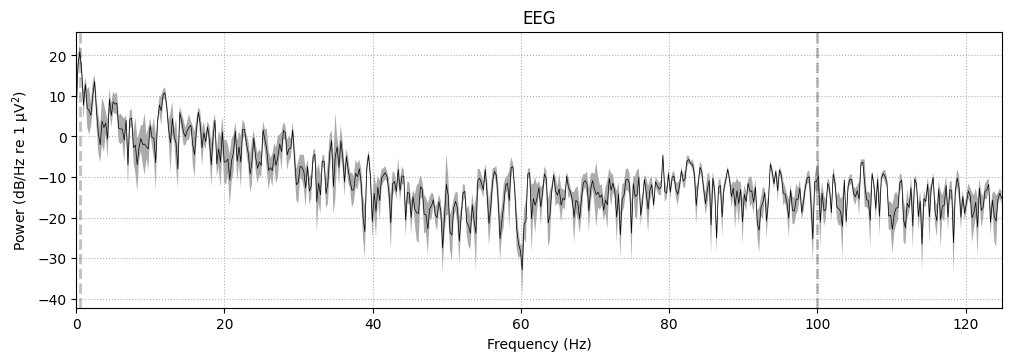

In [96]:
data.plot_psd(tmin=0.5, tmax=4.5, average=True)

In [103]:
data.filter(l_freq=0., h_freq=40., fir_design='firwin', verbose=True)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 83 samples (0.332 s)



<RawGDF | A01E.gdf, 22 x 687000 (2748.0 s), ~115.3 MiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.004 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


d:\PROJ\EEG_Research\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


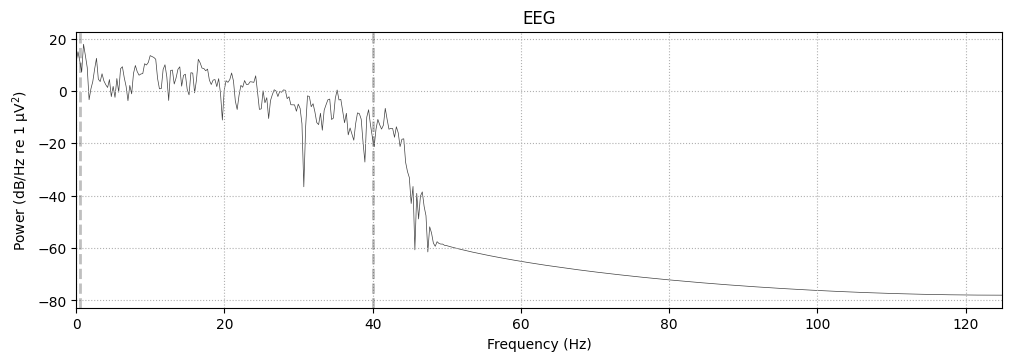

In [113]:
data.plot_psd(tmin=2, tmax=6, picks=['C3'])

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.004 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


d:\PROJ\EEG_Research\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


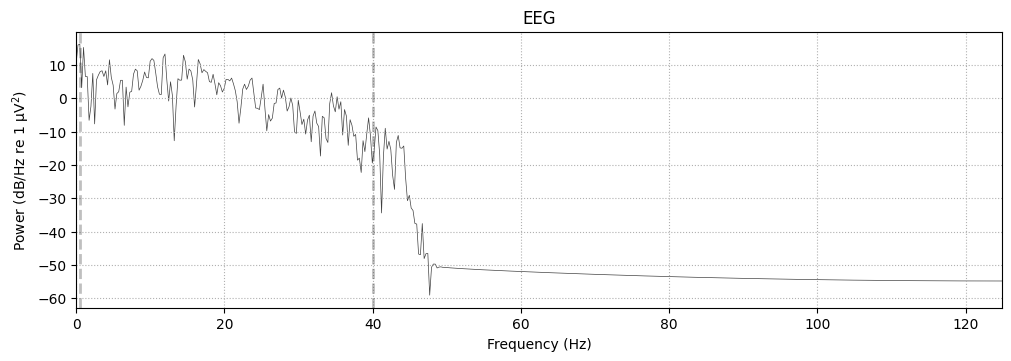

In [114]:
data.plot_psd(tmin=2, tmax=6, picks=['C4'])

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.004 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


d:\PROJ\EEG_Research\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


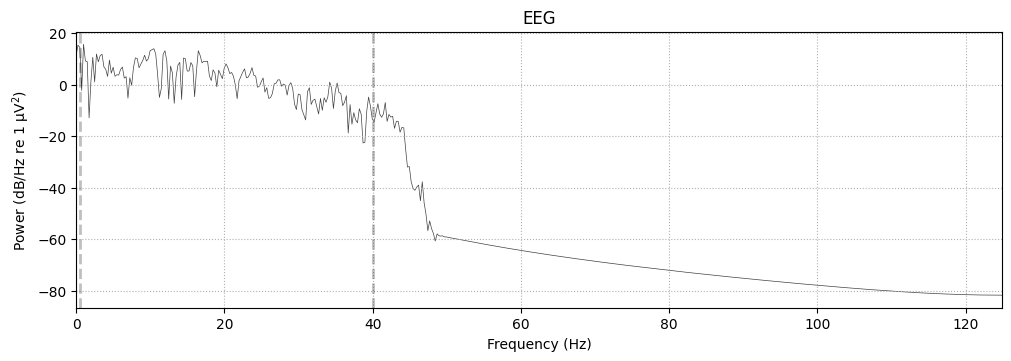

In [115]:
data.plot_psd(tmin=2, tmax=6, picks=['Cz'])

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.004 (s)
Plotting power spectral density (dB=True).


d:\PROJ\EEG_Research\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


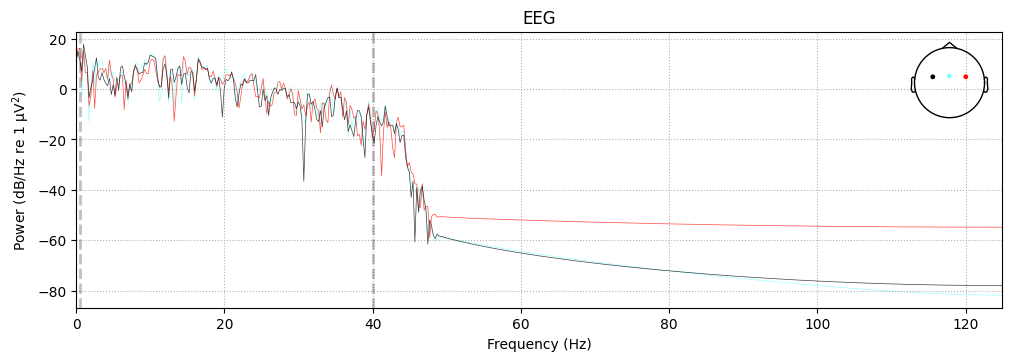

In [118]:
data.plot_psd(tmin=2, tmax=6, picks=['C3', 'Cz', 'C4'])

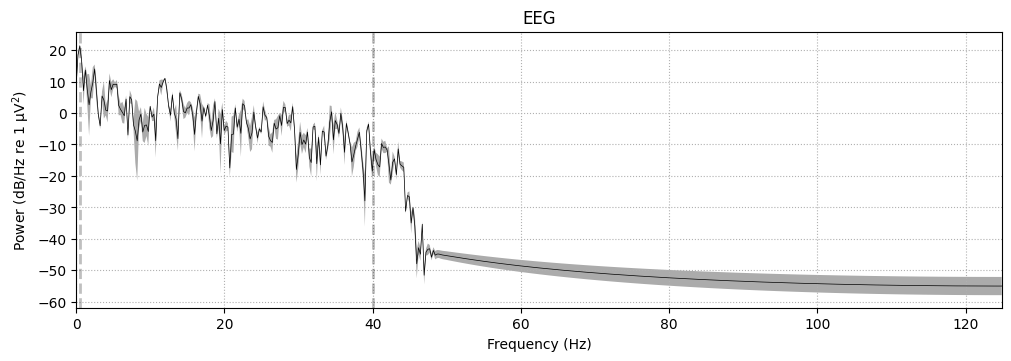

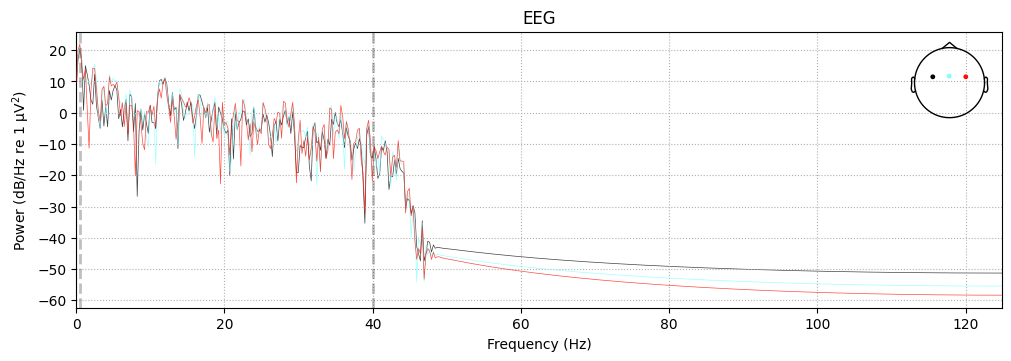

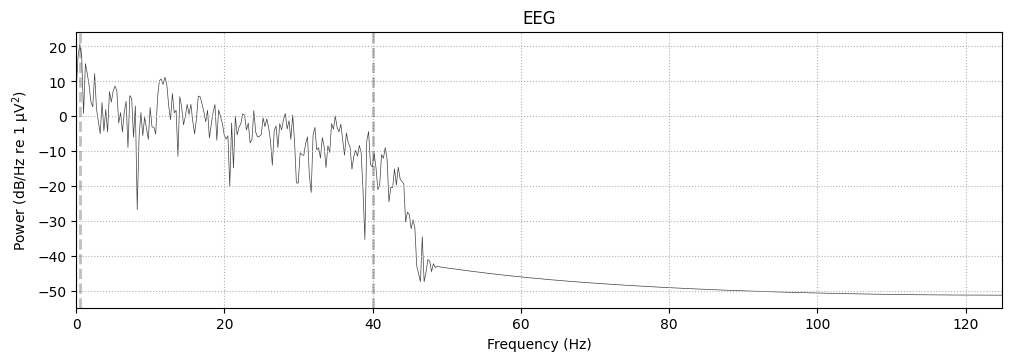

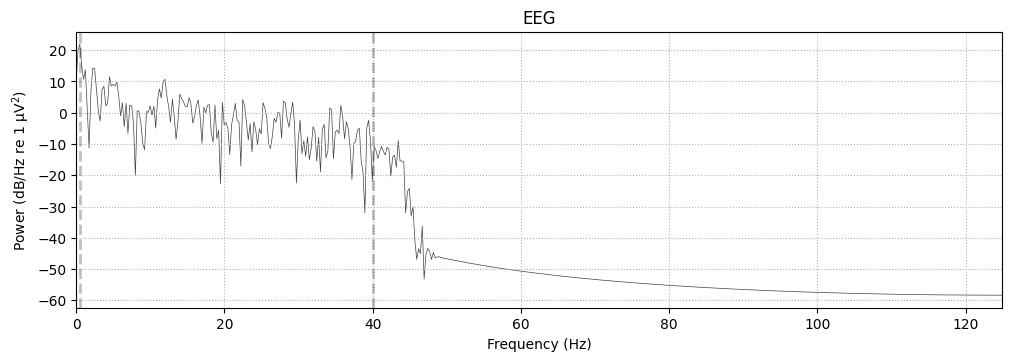

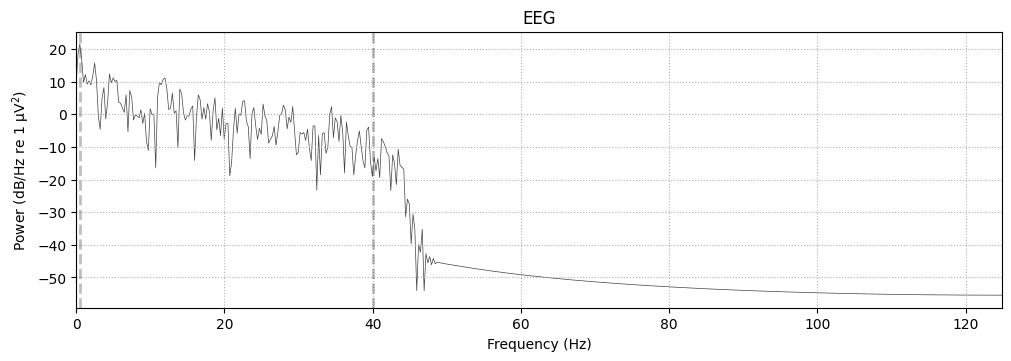

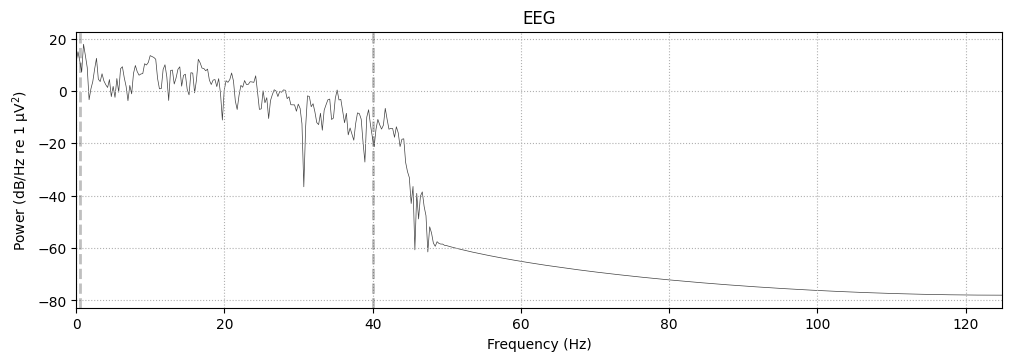

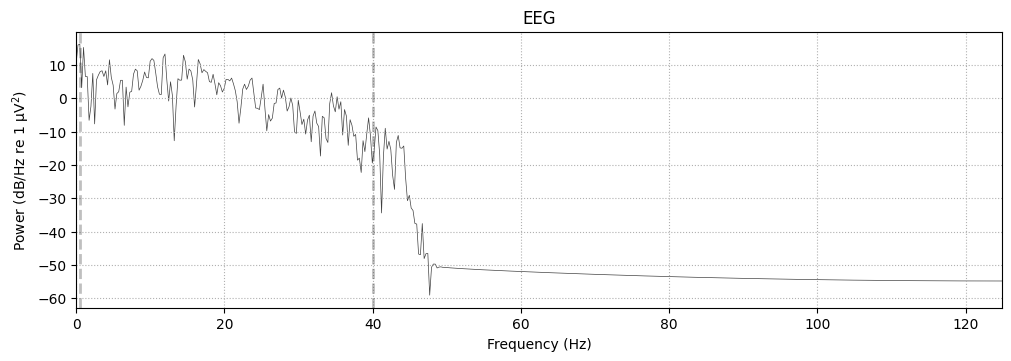

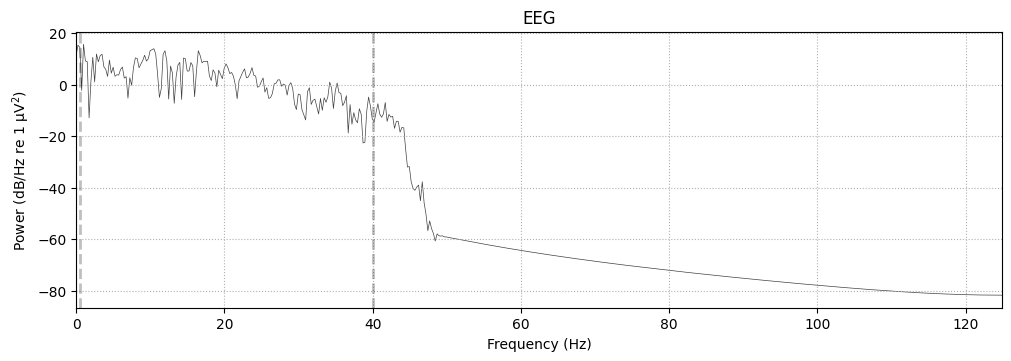

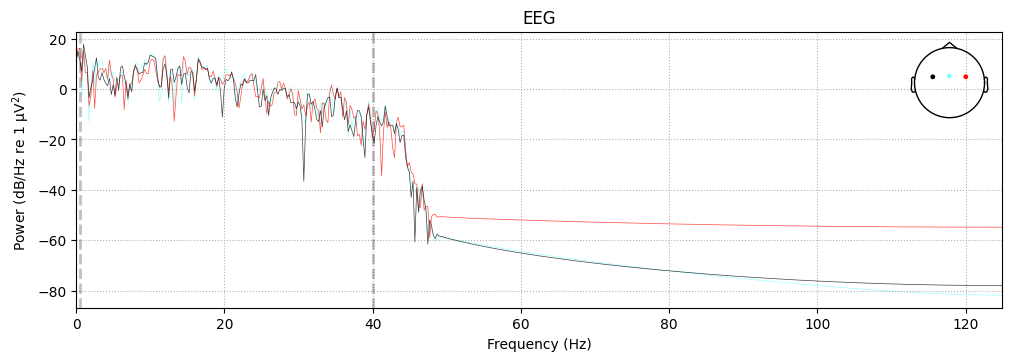

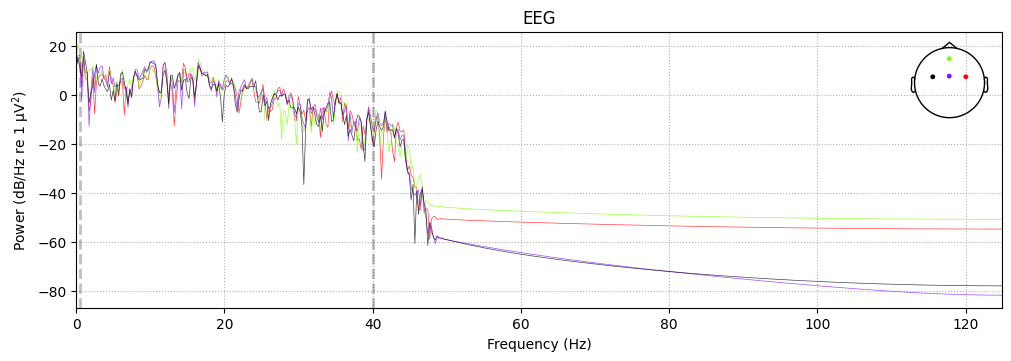

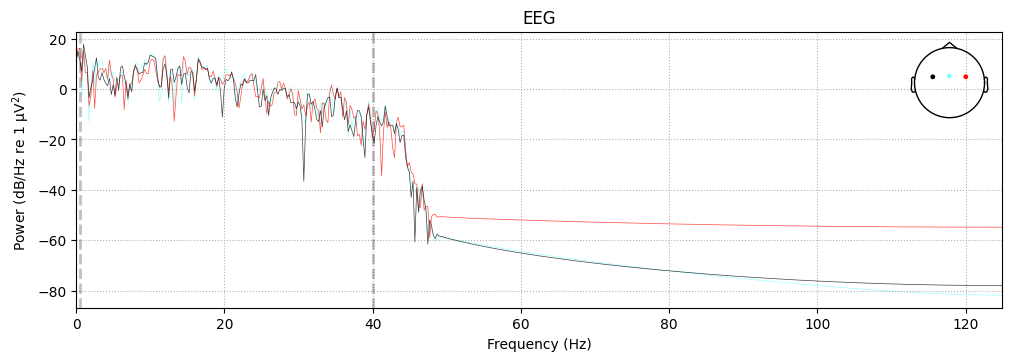

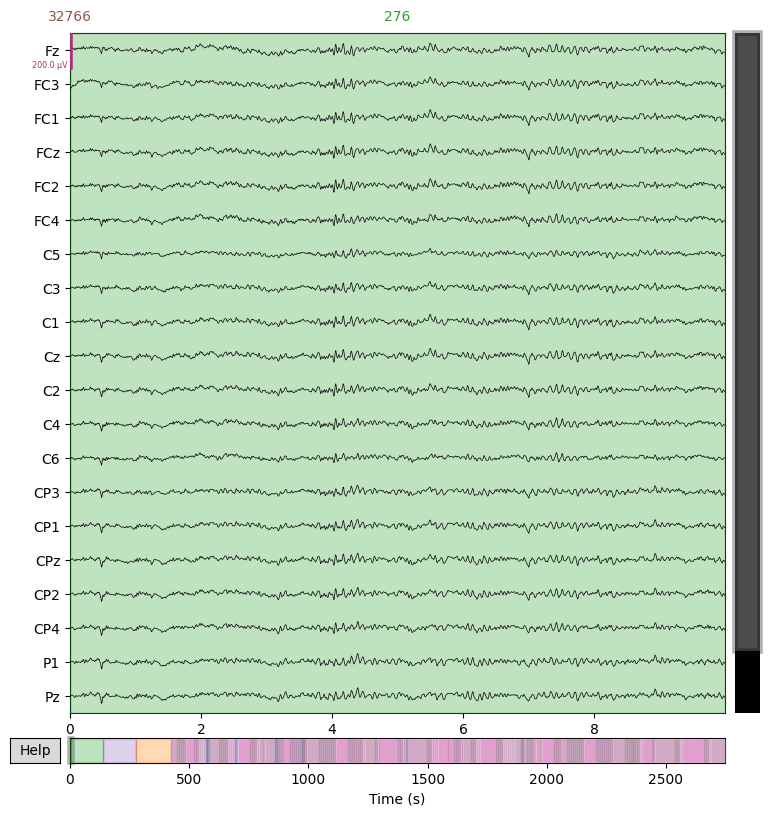

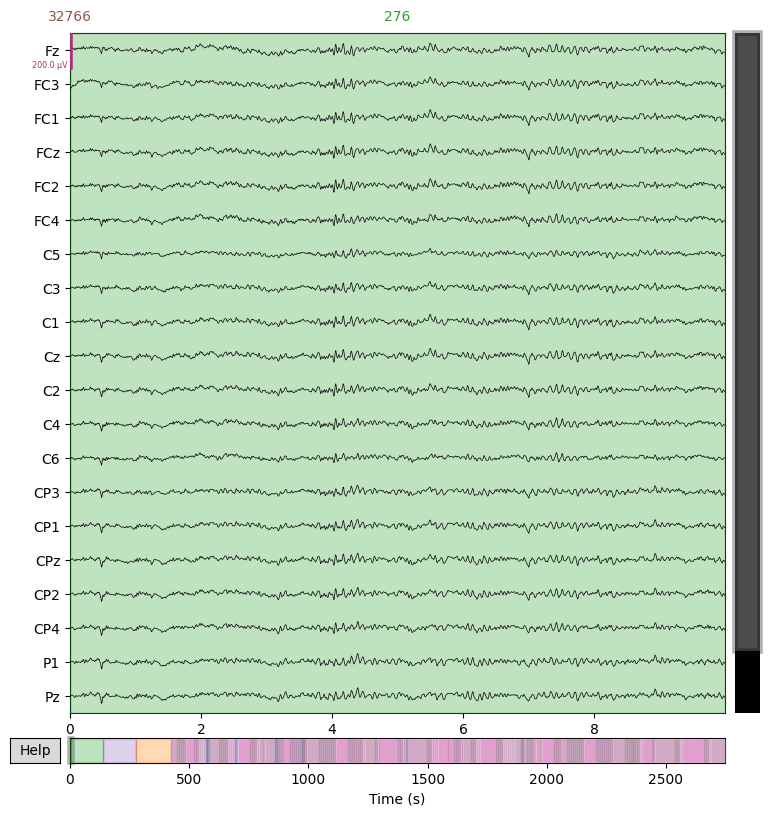

In [119]:
data.plot(scalings = dict(eeg=100e-6))

In [120]:
from mne.preprocessing import ICA
num_components = 22
ica = ICA(n_components=num_components, method='fastica', random_state=42)
ica.fit(data)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 22 components
Fitting ICA took 20.9s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,47 iterations on raw data (687000 samples)
ICA components,22
Available PCA components,22
Channel types,eeg
ICA components marked for exclusion,—


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1374 matching events found
No baseline correction appl

d:\PROJ\EEG_Research\.venv\Lib\site-packages\mne\viz\ica.py:188: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize, facecolor=[0.95] * 3)


Not setting metadata
1374 matching events found
No baseline correction applied
0 projection items activated


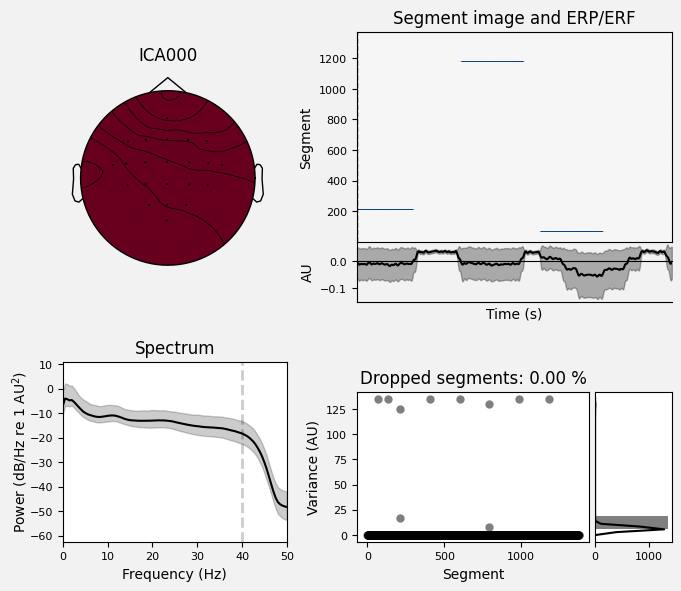

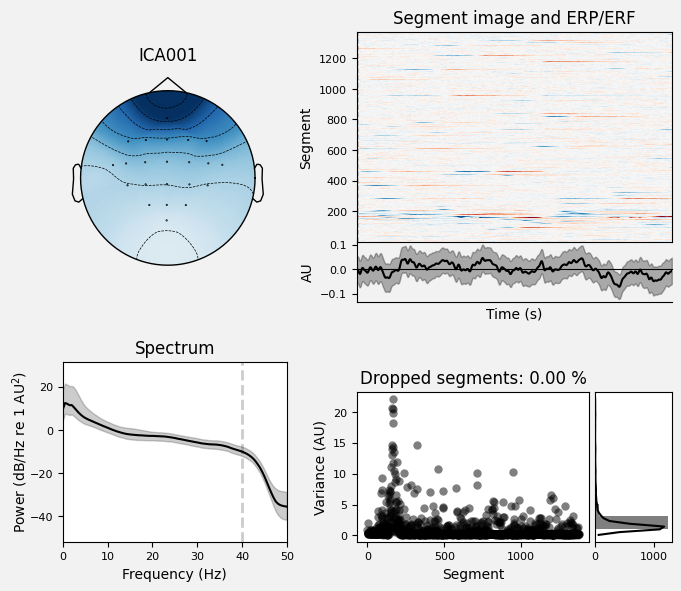

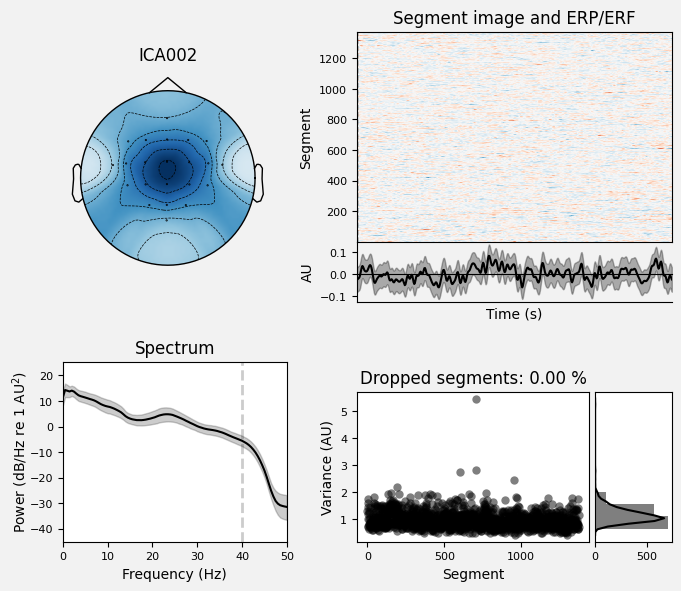

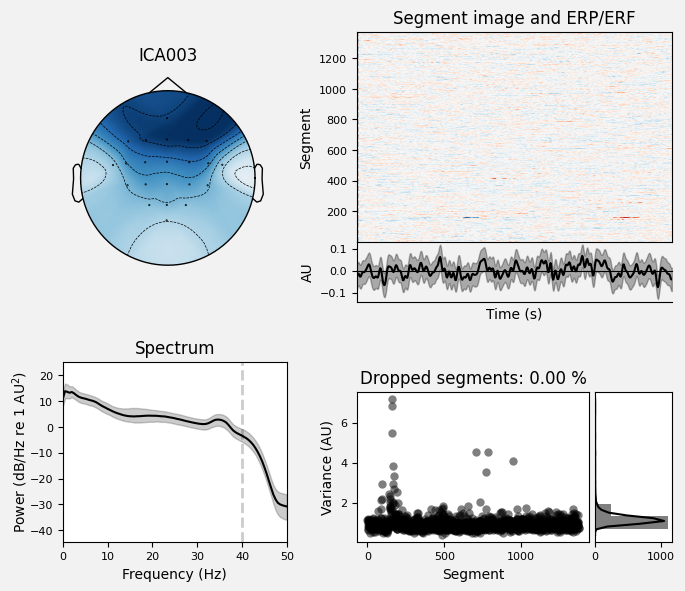

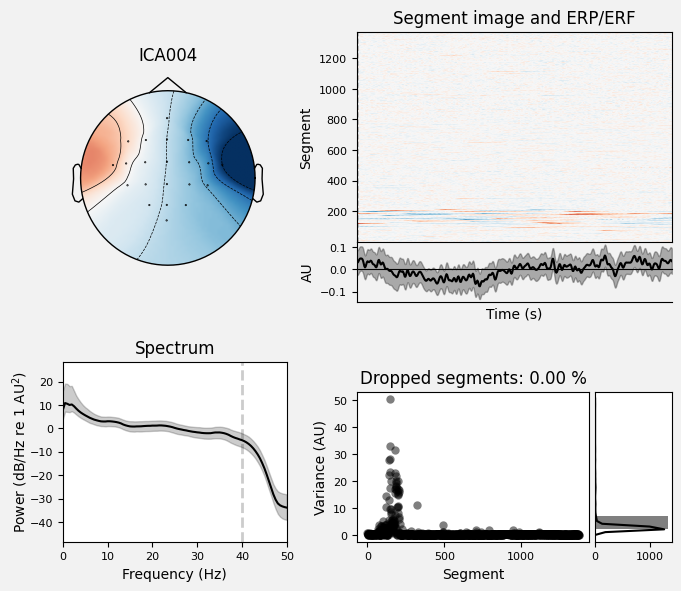

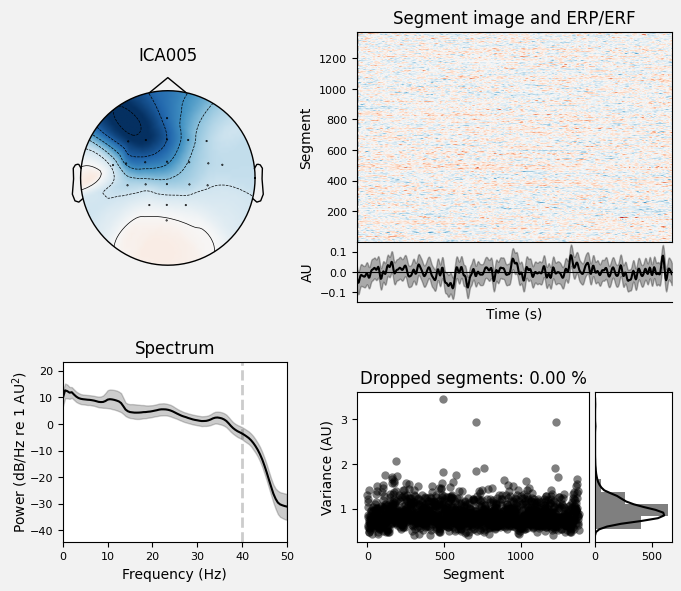

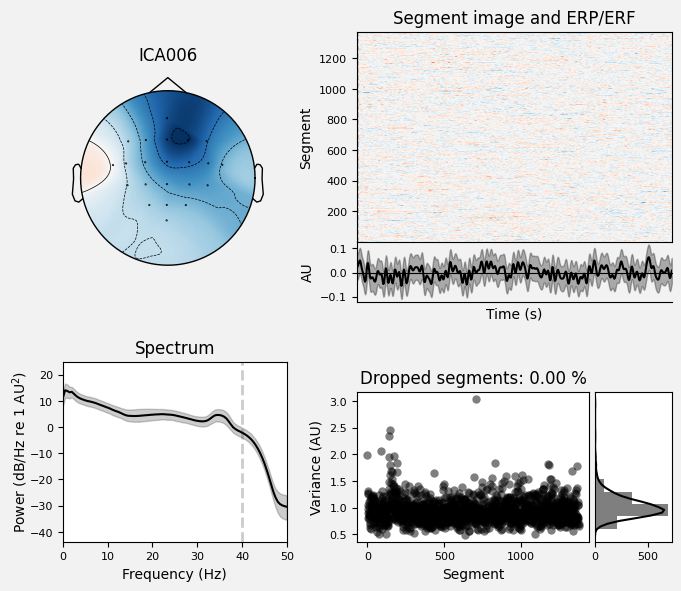

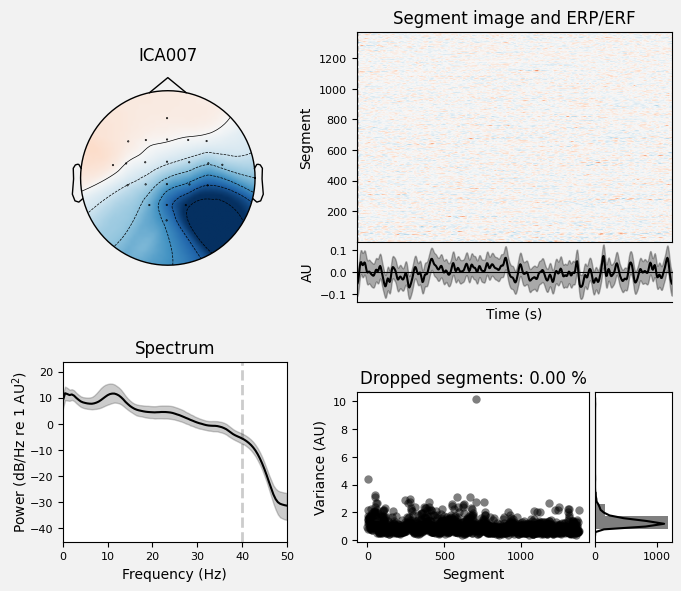

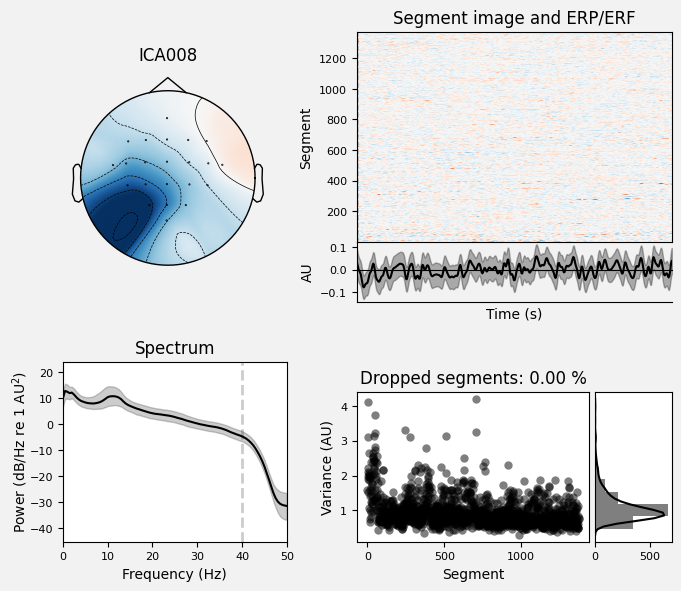

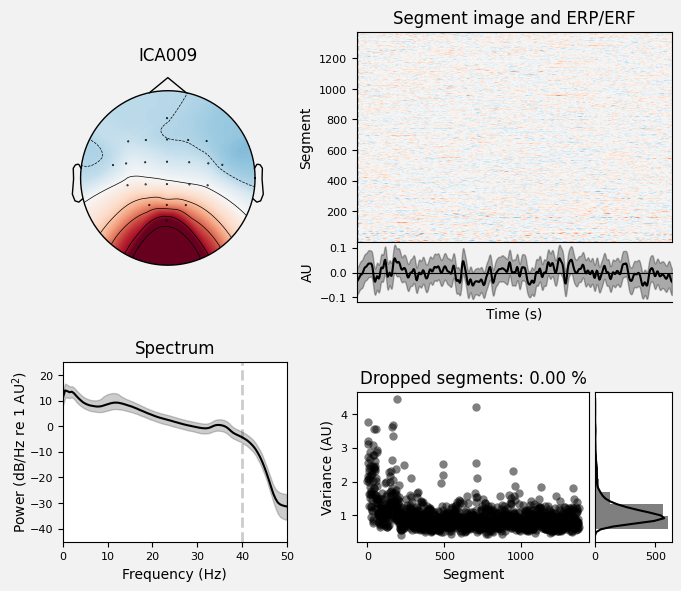

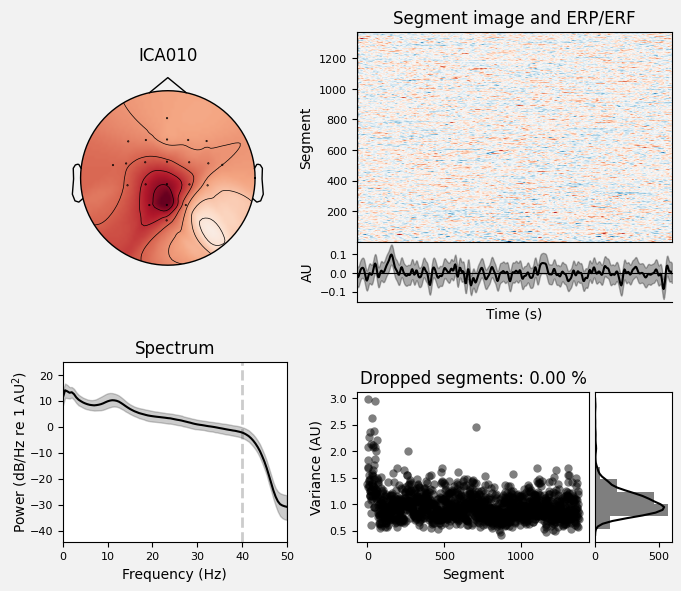

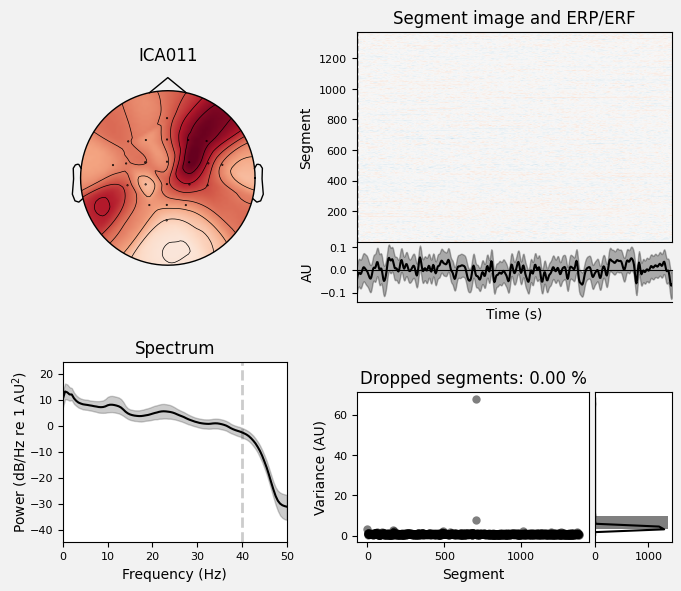

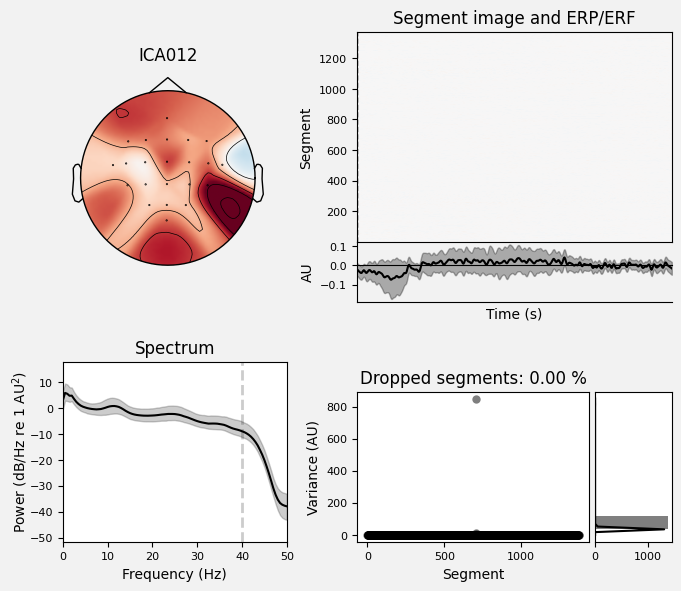

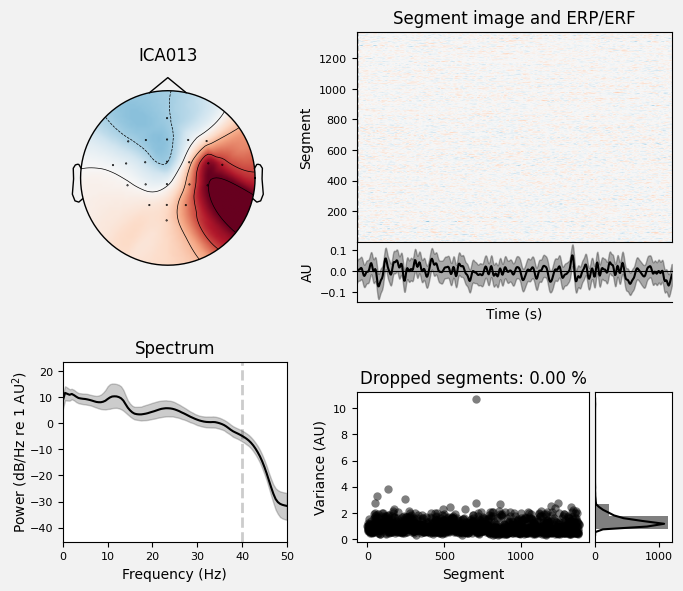

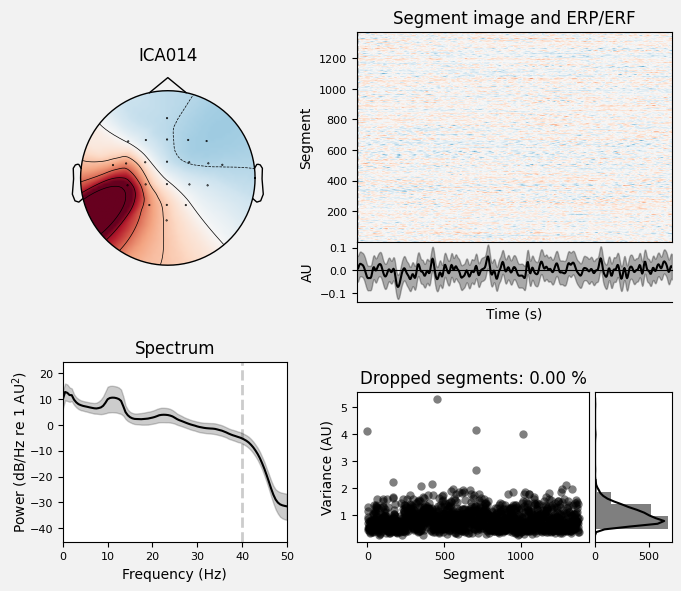

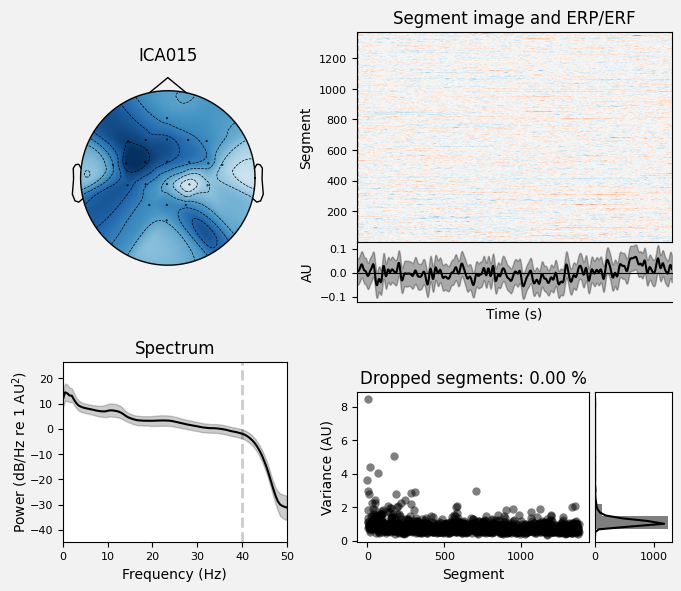

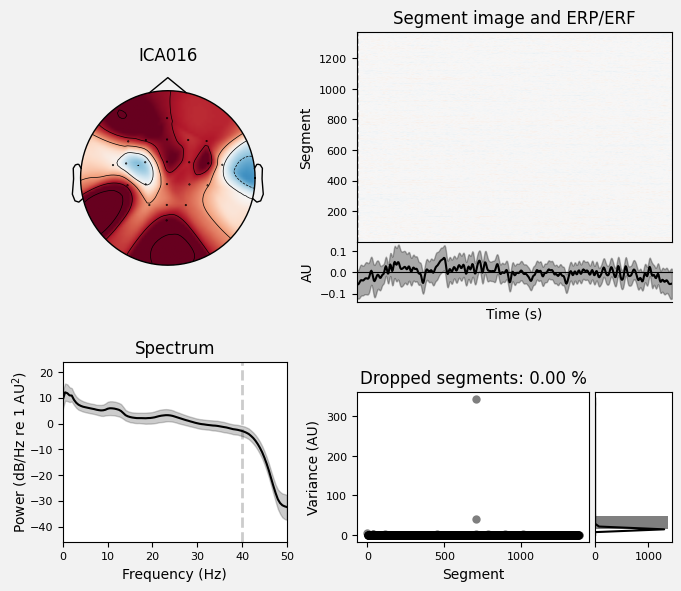

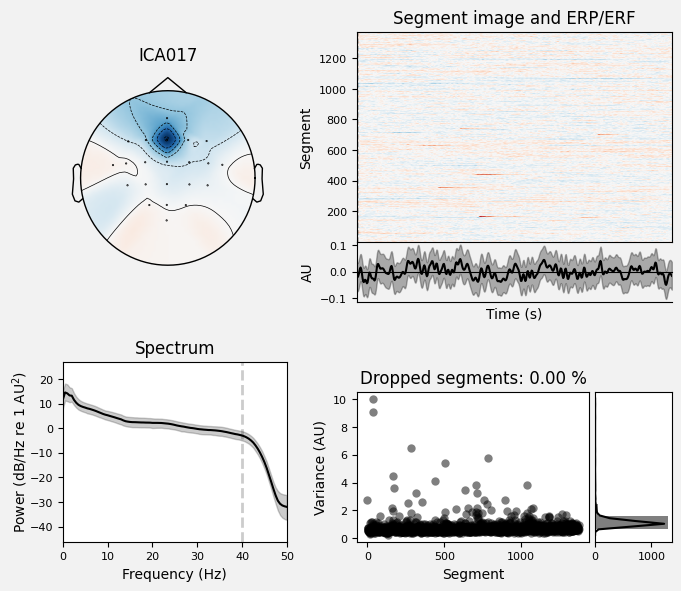

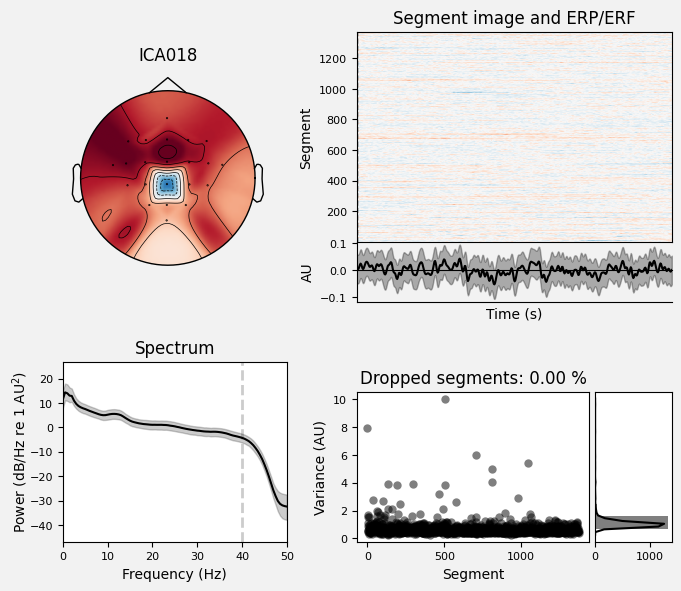

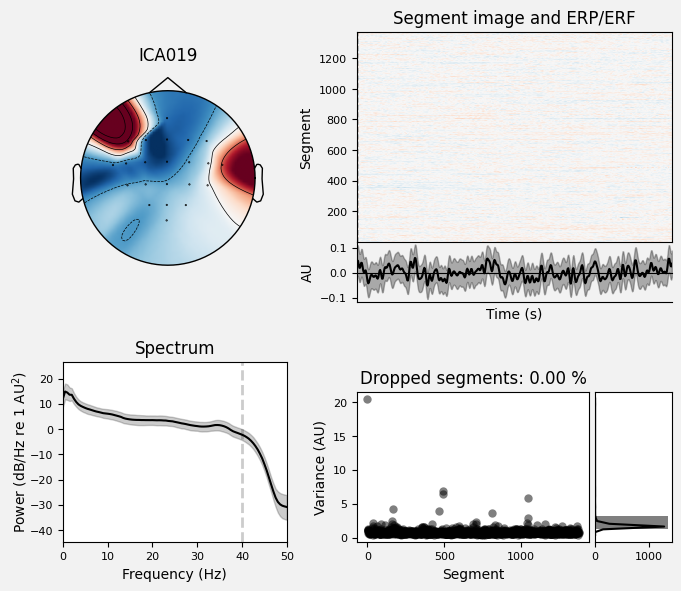

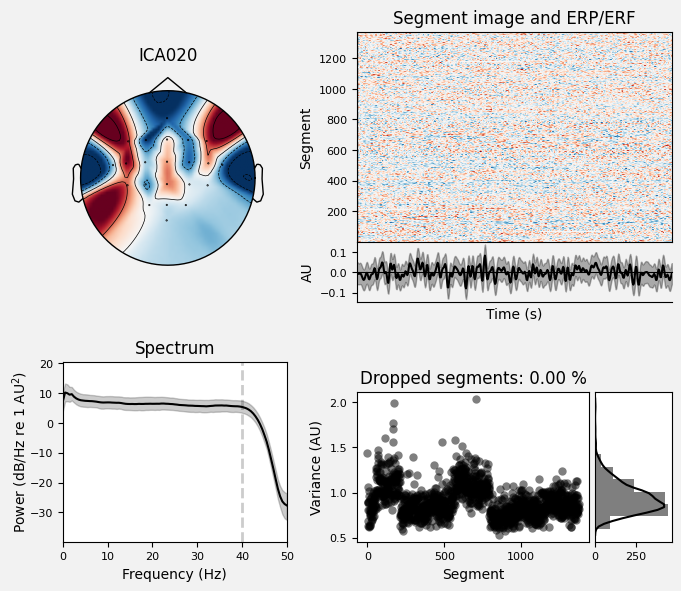

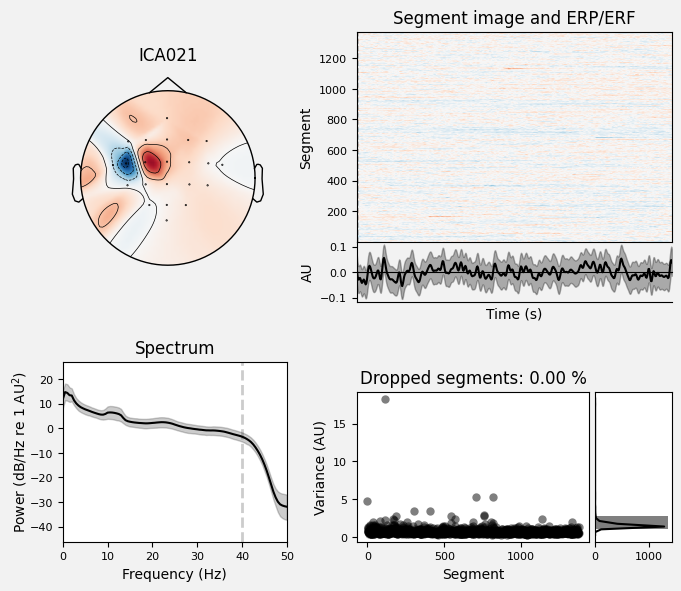

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [121]:
ica.plot_properties(data, picks=range(num_components))